# 4 — Valutazione quantitativa

100 MRI sintetiche vs reali, su **test set** (102) e **intero dataset** (1007):

- **FID 2.5D** (3 piani XY/YZ/ZX): realismo distribuzionale. Piu' basso = meglio.
- **MMD**: distanza distribuzionale complementare. Piu' basso = meglio.
- **MS-SSIM** intra-set: diversita' (controllo mode collapse).

Piu' la **curva FID-vs-epoca** dalla selezione dei checkpoint.

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s // 2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes=ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Tabella riassuntiva delle metriche

In [2]:
with open("outputs/metrics/eval_test.json") as f: ev_test=json.load(f)
with open("outputs/metrics/eval_all.json") as f: ev_all=json.load(f)

rows = [
    ("FID XY",        "fid_xy"),
    ("FID YZ",        "fid_yz"),
    ("FID ZX",        "fid_zx"),
    ("FID medio",     "fid_avg"),
    ("MMD",           "mmd"),
    ("MS-SSIM sint",  "msssim_synth"),
    ("MS-SSIM reali", "msssim_real"),
]
h_metric, h_test, h_all="Metrica", "test (102)", "all (1007)"
print(f"{h_metric:<15}{h_test:>14}{h_all:>14}")
print("-"*43)
for name, key in rows:
    print(f"{name:<15}{ev_test[key]:>14.4f}{ev_all[key]:>14.4f}")

Metrica            test (102)    all (1007)
-------------------------------------------
FID XY                84.6260       83.8691
FID YZ               100.5135       99.6361
FID ZX                81.0598       80.0920
FID medio             88.7331       87.8658
MMD                    0.0078        0.0078
MS-SSIM sint           0.9505        0.9505
MS-SSIM reali          0.9357        0.9355


## Curva FID-vs-epoca

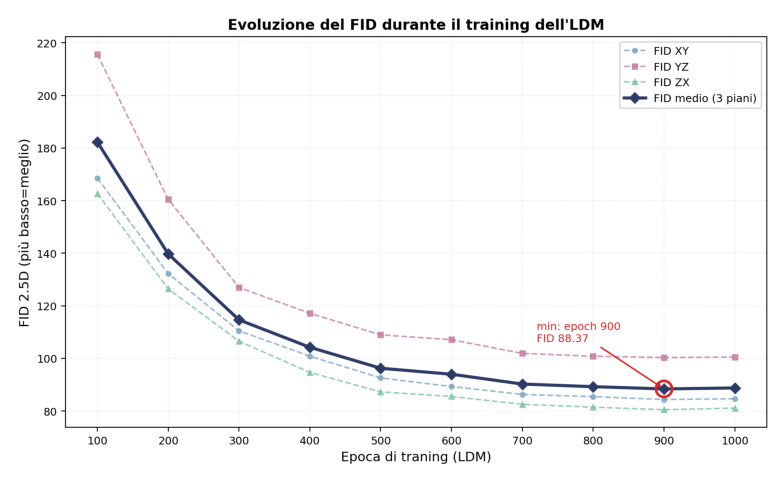

In [3]:
fig_path="outputs/metrics/fid_vs_epoch.png"
if os.path.exists(fig_path):
    fig, ax=plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(fig_path)); ax.axis("off"); plt.show()
else:
    from src.evaluation.plot_fid_curve import plot_fid_curve
    plot_fid_curve("outputs/metrics/fid_by_checkpoint.json",
                   save_path="outputs/metrics/fid_vs_epoch.png")
    plt.show()

## Lettura dei risultati

- **FID** quasi identico su test (88.7) e all (87.9): metrica stabile, nessuna memorizzazione.
- **MMD** molto basso (~0.008): distribuzioni vicine.
- **MS-SSIM** sint (~0.95) ~ reali (~0.94): diversita' paragonabile ai reali -> **no mode collapse**.
- Piano **YZ** con FID piu' alto (corteccia sagittale piu' difficile), coerente a ogni epoca.

Il FID si stabilizza verso epoch 800-900: training a saturazione, checkpoint finale (1000) equivalente al minimo -> modello robusto.